# Pyramidal CNN-BiLSTM Architecture Diagram (PlotNeuralNet)

Paper 04 (Wang C. et al. — PCNN-BiLSTM): Stride-based pyramidal CNN + BiLSTM

## Architecture Summary
- **33,442 parameters** (lightweight)
- 3 strided conv blocks create a pyramid: 2048 → 683 → 342 → 171 timesteps
- BiLSTM with mean pooling for temporal aggregation
- Dense classifier

| Block | Operation | Output Shape |
|-------|-----------|-------------|
| Input | — | (B, 4, 2048) |
| Conv Block 1 | Conv1d(4→16, k=5, s=3) + BN + ReLU | (B, 16, 683) |
| Conv Block 2 | Conv1d(16→32, k=3, s=2) + BN + ReLU | (B, 32, 342) |
| Conv Block 3 | Conv1d(32→64, k=3, s=2) + BN + ReLU | (B, 64, 171) |
| BiLSTM | LSTM(64→32, bidir) | (B, 171, 64) |
| Mean Pool | avg over time | (B, 64) |
| Classifier | Dropout(0.1) + Dense(64→2) | (B, 2) |

### PlotNeuralNet scaling:
- **height=depth** ∝ sequence length: 2048→40, 683→13, 342→7, 171→4
- **width** ∝ channels: 4→0.5, 16→1.5, 32→3, 64→6

In [1]:
import sys, os
sys.path.append('PlotNeuralNet')
from pycore.tikzeng import *

In [2]:
arch = [
    to_head('PlotNeuralNet'),
    to_cor(),
    to_begin(),

    # === INPUT ===
    # 4 channels × 2048 timesteps
    # height=depth=40 (2048 timesteps), width=0.5 (4 channels)
    to_Conv(
        name="input",
        s_filer="",
        n_filer=4,
        offset="(0,0,0)",
        to="(0,0,0)",
        width=0.5,
        height=40,
        depth=40,
        caption="Input"
    ),

    # === CONV BLOCK 1 ===
    # Conv1d(4→16, k=5, stride=3) + BN + ReLU
    # 2048/3 ≈ 683 timesteps → height=depth=13
    # 16 channels → width=1.5
    to_Conv(
        name="conv1",
        s_filer="",
        n_filer=16,
        offset="(2,0,0)",
        to="(input-east)",
        width=1.5,
        height=13,
        depth=13,
        caption="Conv$_1$ s=3"
    ),
    to_connection("input", "conv1"),

    # === CONV BLOCK 2 ===
    # Conv1d(16→32, k=3, stride=2) + BN + ReLU
    # 683/2 ≈ 342 timesteps → height=depth=7
    # 32 channels → width=3
    to_Conv(
        name="conv2",
        s_filer="",
        n_filer=32,
        offset="(2,0,0)",
        to="(conv1-east)",
        width=3,
        height=7,
        depth=7,
        caption="Conv$_2$ s=2"
    ),
    to_connection("conv1", "conv2"),

    # === CONV BLOCK 3 ===
    # Conv1d(32→64, k=3, stride=2) + BN + ReLU
    # 342/2 ≈ 171 timesteps → height=depth=4
    # 64 channels → width=6
    to_Conv(
        name="conv3",
        s_filer="",
        n_filer=64,
        offset="(2,0,0)",
        to="(conv2-east)",
        width=6,
        height=4,
        depth=4,
        caption="Conv$_3$ s=2"
    ),
    to_connection("conv2", "conv3"),

    # === BiLSTM ===
    # LSTM(64→32, bidirectional) → 64-dim output, 171 timesteps
    # Same spatial size as conv3 (171 steps), same features (64)
    to_Conv(
        name="lstm",
        s_filer="",
        n_filer=64,
        offset="(2.5,0,0)",
        to="(conv3-east)",
        width=6,
        height=4,
        depth=4,
        caption="BiLSTM"
    ),
    to_connection("conv3", "lstm"),

    # === GLOBAL MEAN POOLING ===
    # Average over 171 timesteps → (B, 64)
    to_Pool(
        name="gap",
        offset="(0,0,0)",
        to="(lstm-east)",
        width=3,
        height=3,
        depth=3,
        opacity=0.5,
        caption="Mean Pool"
    ),

    # === DENSE CLASSIFIER ===
    # Dropout(0.1) + Dense(64→2)
    to_SoftMax(
        name="fc",
        s_filer=2,
        offset="(2,0,0)",
        to="(gap-east)",
        width=1.5,
        height=3,
        depth=15,
        caption="FC"
    ),
    to_connection("gap", "fc"),

    to_end()
]

to_generate(arch, 'pyramidal_cnn_bilstm.tex')
print("Generated: pyramidal_cnn_bilstm.tex")


\documentclass[border=8pt, multi, tikz]{standalone} 
\usepackage{import}
\subimport{PlotNeuralNet/layers/}{init}
\usetikzlibrary{positioning}
\usetikzlibrary{3d} %for including external image 


\def\ConvColor{rgb:yellow,5;red,2.5;white,5}
\def\ConvReluColor{rgb:yellow,5;red,5;white,5}
\def\PoolColor{rgb:red,1;black,0.3}
\def\UnpoolColor{rgb:blue,2;green,1;black,0.3}
\def\FcColor{rgb:blue,5;red,2.5;white,5}
\def\FcReluColor{rgb:blue,5;red,5;white,4}
\def\SoftmaxColor{rgb:magenta,5;black,7}   
\def\SumColor{rgb:blue,5;green,15}


\newcommand{\copymidarrow}{\tikz \draw[-Stealth,line width=0.8mm,draw={rgb:blue,4;red,1;green,1;black,3}] (-0.3,0) -- ++(0.3,0);}

\begin{document}
\begin{tikzpicture}
\tikzstyle{connection}=[ultra thick,every node/.style={sloped,allow upside down},draw=\edgecolor,opacity=0.7]
\tikzstyle{copyconnection}=[ultra thick,every node/.style={sloped,allow upside down},draw={rgb:blue,4;red,1;green,1;black,3},opacity=0.7]


\pic[shift={(0,0,0)}] at (0,0,0) 
    {Box={
 

In [3]:
# Post-process: add custom colors for LSTM block
with open('pyramidal_cnn_bilstm.tex', 'r') as f:
    tex = f.read()

# Add custom color definitions
color_defs = r"""
% Custom colors
\def\LstmColor{rgb:green,4;blue,1;white,3}
\def\InputColor{rgb:blue,1;white,8}
"""
tex = tex.replace(r'\def\SumColor{rgb:blue,5;green,15}',
                  r'\def\SumColor{rgb:blue,5;green,15}' + color_defs)

# Color the input block
tex = tex.replace(
    'name=input,\n        caption=Input,\n        xlabel={{4, }},\n        zlabel=,\n        fill=\\ConvColor,',
    'name=input,\n        caption=Input,\n        xlabel={{4, }},\n        zlabel=,\n        fill=\\InputColor,'
)
# Color the LSTM block
tex = tex.replace(
    'name=lstm,\n        caption=BiLSTM,\n        xlabel={{64, }},\n        zlabel=,\n        fill=\\ConvColor,',
    'name=lstm,\n        caption=BiLSTM,\n        xlabel={{64, }},\n        zlabel=,\n        fill=\\LstmColor,'
)

with open('pyramidal_cnn_bilstm.tex', 'w') as f:
    f.write(tex)

print("Colors applied:")
print("  Input  → light blue")
print("  Conv1-3 → yellow-orange (pyramidal shrinking)")
print("  BiLSTM → green")
print("  Pool   → dark red")
print("  FC     → purple")

Colors applied:
  Input  → light blue
  Conv1-3 → yellow-orange (pyramidal shrinking)
  BiLSTM → green
  Pool   → dark red
  FC     → purple


In [4]:
# Compile to PDF and PNG
import subprocess

result = subprocess.run(
    ['pdflatex', '-interaction=nonstopmode', 'pyramidal_cnn_bilstm.tex'],
    capture_output=True, text=True, cwd=os.getcwd()
)

if 'Output written' in result.stdout:
    print("PDF generated: pyramidal_cnn_bilstm.pdf")
    subprocess.run(
        ['pdftoppm', '-png', '-r', '250', 'pyramidal_cnn_bilstm.pdf', 'pyramidal_cnn_bilstm_preview'],
        cwd=os.getcwd()
    )
    print("PNG preview: pyramidal_cnn_bilstm_preview-1.png")
else:
    print("ERROR:")
    print('\n'.join(result.stdout.split('\n')[-20:]))

PDF generated: pyramidal_cnn_bilstm.pdf
PNG preview: pyramidal_cnn_bilstm_preview-1.png


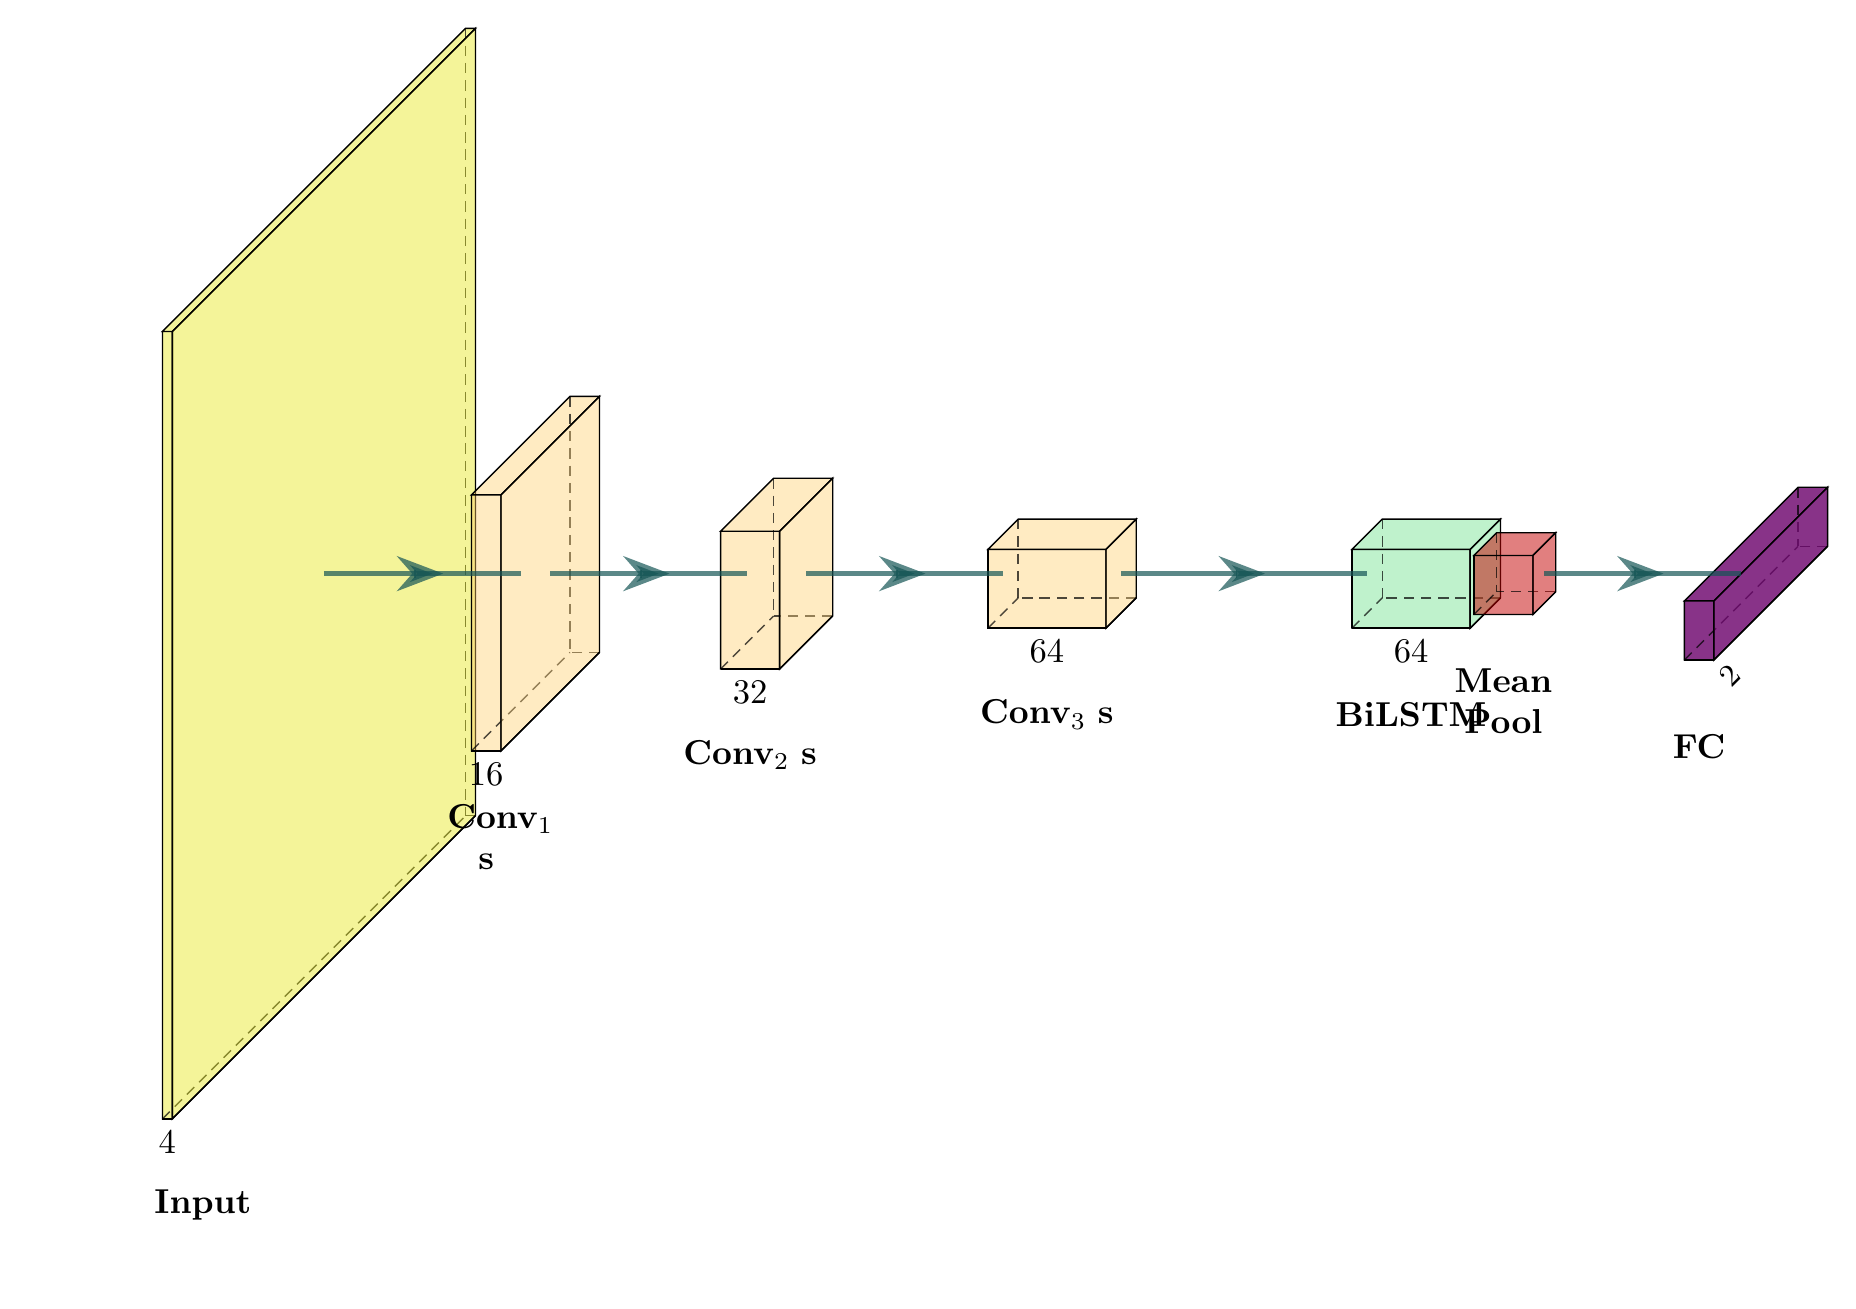

In [5]:
from IPython.display import Image, display
display(Image('pyramidal_cnn_bilstm_preview-1.png'))